In [1]:
# 挂载Drive+安装依赖
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 1. 直接在 Colab 中下载中文字体（黑体）
!wget -q -O SimHei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 2. 将下载的字体加载到 Matplotlib 的字体管理器中
fm.fontManager.addfont('SimHei.ttf')

# 3. 将全局字体设置为刚刚加载的黑体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题

print("中文字体配置成功！")

中文字体配置成功！


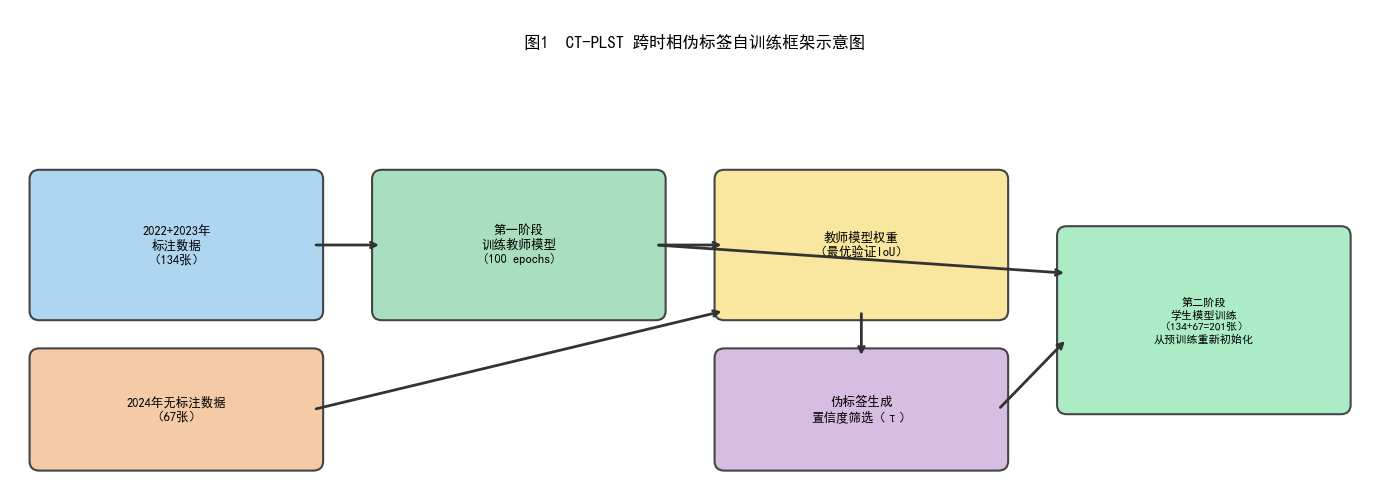

In [3]:
# 图1：CT-PLST框架示意图（流程图）
# ============================================================
# 图1：CT-PLST 跨时相伪标签自训练框架流程示意图
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

def draw_box(ax, x, y, w, h, color, text, fontsize=10):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='#444', linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

# 第一阶段
draw_box(ax, 0.3, 1.8, 2.8, 1.4, '#AED6F1',
         '2022+2023年\n标注数据\n（134张）', fontsize=9)
draw_box(ax, 3.8, 1.8, 2.8, 1.4, '#A9DFBF',
         '第一阶段\n训练教师模型\n(100 epochs)', fontsize=9)
draw_box(ax, 7.3, 1.8, 2.8, 1.4, '#F9E79F',
         '教师模型权重\n（最优验证IoU）', fontsize=9)

draw_arrow(ax, 3.1, 2.5, 3.8, 2.5)
draw_arrow(ax, 6.6, 2.5, 7.3, 2.5)

# 第二阶段输入
draw_box(ax, 0.3, 0.2, 2.8, 1.1, '#F5CBA7',
         '2024年无标注数据\n（67张）', fontsize=9)
draw_arrow(ax, 3.1, 0.75, 7.3, 1.8)  # 斜向箭头

# 伪标签生成
draw_box(ax, 7.3, 0.2, 2.8, 1.1, '#D7BDE2',
         '伪标签生成\n置信度筛选（τ）', fontsize=9)
draw_arrow(ax, 8.7, 1.8, 8.7, 1.3)

# 合并 + 学生模型
draw_box(ax, 10.8, 0.8, 2.8, 1.8, '#ABEBC6',
         '第二阶段\n学生模型训练\n（134+67=201张）\n从预训练重新初始化', fontsize=8)
draw_arrow(ax, 10.1, 0.75, 10.8, 1.5)
draw_arrow(ax, 6.6, 2.5, 10.8, 2.2)

ax.text(7.0, 4.6, '图1  CT-PLST 跨时相伪标签自训练框架示意图',
        ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_ct_plst_framework.png', dpi=200, bbox_inches='tight')
plt.show()

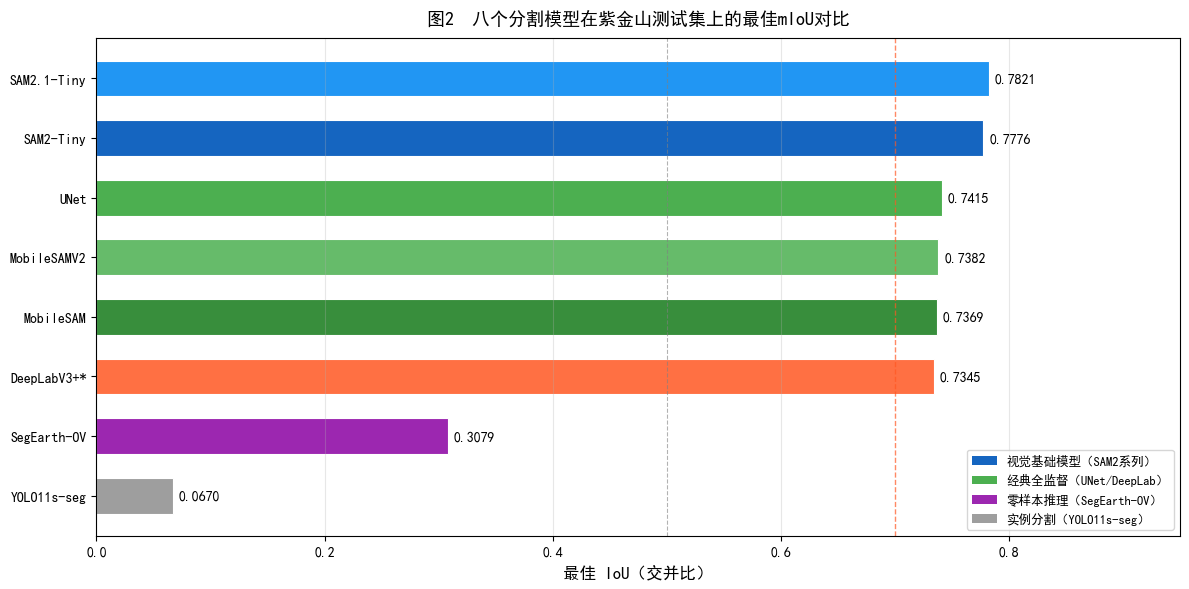

In [4]:
# 图2：八模型最佳mIoU横向对比柱状图（紫金山数据集）
# ============================================================
# 图2：八个模型最佳mIoU对比柱状图（紫金山测试集）
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 数据（请替换为实际结果）──
models = ['SAM2.1-Tiny', 'SAM2-Tiny', 'UNet', 'MobileSAMV2',
          'MobileSAM', 'DeepLabV3+*', 'SegEarth-OV', 'YOLO11s-seg']
iou_values = [0.7821, 0.7776, 0.7415, 0.7382, 0.7369, 0.7345, 0.3079, 0.0670]

# 按范式着色
colors = ['#2196F3', '#1565C0',          # SAM2系列：蓝色
          '#4CAF50',                       # UNet：绿色
          '#66BB6A', '#388E3C',            # MobileSAM系列：浅绿
          '#FF7043',                       # DeepLabV3+：橙
          '#9C27B0',                       # SegEarth-OV：紫
          '#9E9E9E']                       # YOLO：灰

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(models[::-1], iou_values[::-1], color=colors[::-1],
               edgecolor='white', linewidth=0.8, height=0.6)

# 添加数值标签
for bar, val in zip(bars, iou_values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=10, fontweight='bold')

# 参考线
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(x=0.7, color='#FF5722', linestyle='--', linewidth=1.0, alpha=0.7,
           label='IoU=0.70 参考线')

ax.set_xlabel('最佳 IoU（交并比）', fontsize=12)
ax.set_title('图2  八个分割模型在紫金山测试集上的最佳mIoU对比', fontsize=13, pad=10)
ax.set_xlim(0, 0.95)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# 范式图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='视觉基础模型（SAM2系列）'),
    Patch(facecolor='#4CAF50', label='经典全监督（UNet/DeepLab）'),
    Patch(facecolor='#9C27B0', label='零样本推理（SegEarth-OV）'),
    Patch(facecolor='#9E9E9E', label='实例分割（YOLO11s-seg）'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig2_model_iou_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
import os
DRIVE = '/content/drive/MyDrive/vegetation_models_v2'
for root, dirs, files in os.walk(DRIVE):
    for f in files:
        if f.endswith('.json'):
            print(os.path.join(root, f))

/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/demo/frontend/.prettierrc.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/demo/frontend/package.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/demo/frontend/tsconfig.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/demo/frontend/tsconfig.node.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/sav_dataset/example/sav_000001_auto.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/code/sav_dataset/example/sav_000001_manual.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints/train_log.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints_v2/train_log_v2.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints_ablation/log_thr0.7.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints_ablation/log_thr0.75.json
/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints_abla

In [14]:
import json

# 先看紫金山的SAM2-Tiny日志
with open('/content/drive/MyDrive/vegetation_models_v2/1_SAM2_Tiny/checkpoints/train_log.json') as f:
    log = json.load(f)

print(type(log))          # 是dict还是list？
if isinstance(log, dict):
    print(log.keys())     # 看有哪些键
    # 取第一个键看看内容
    first_key = list(log.keys())[0]
    print(f"第一个键: {first_key}")
    print(f"对应值（前5个）: {log[first_key][:5]}")
elif isinstance(log, list):
    print(f"列表长度: {len(log)}")
    print(f"第一个元素: {log[0]}")

<class 'list'>
列表长度: 100
第一个元素: {'epoch': 1, 'loss': 0.1985473584602861, 'iou': 0.7485642043885051, 'acc': 0.8725346017765641, 'f1': 0.841263572503218}


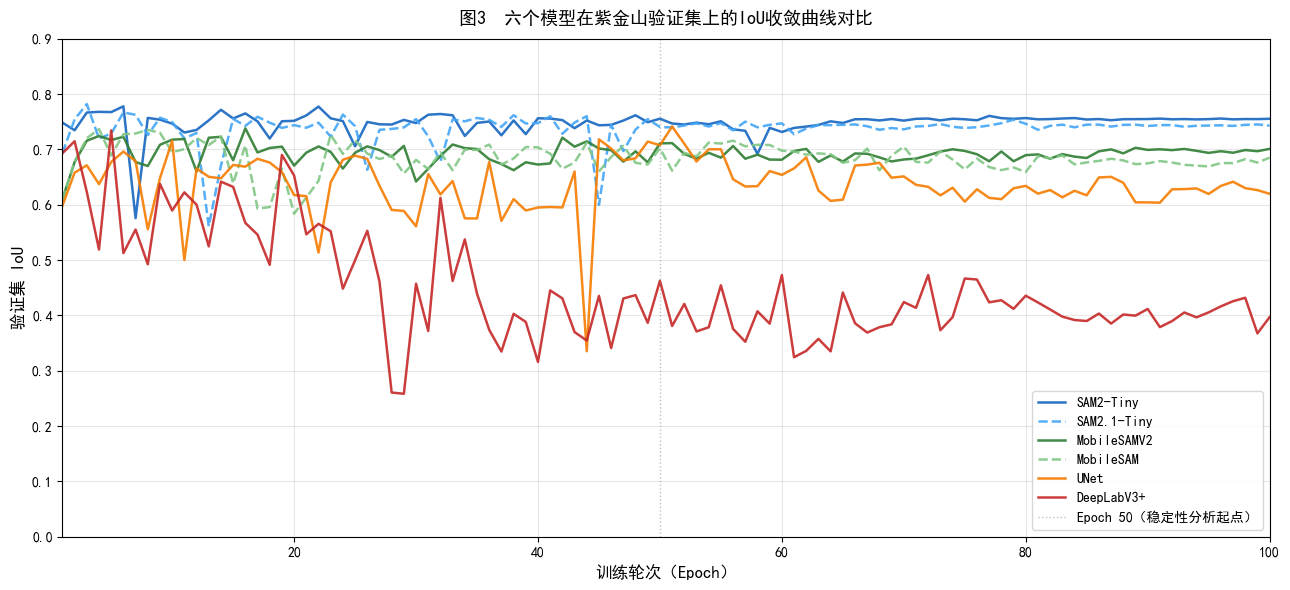

In [15]:
# 图3：六模型IoU训练曲线对比图
# ============================================================
# 图3：六个训练模型的IoU收敛曲线对比
# 使用说明：将 training_logs 替换为各模型实际保存的训练日志
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import json, os

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

DRIVE = '/content/drive/MyDrive/vegetation_models_v2'

# 正确的日志路径和字段名
log_files = {
    'SAM2-Tiny':   f'{DRIVE}/1_SAM2_Tiny/checkpoints/train_log.json',
    'SAM2.1-Tiny': f'{DRIVE}/5_SAM21_Tiny/checkpoints/train_log.json',
    'MobileSAMV2': f'{DRIVE}/6_MobileSAMV2/checkpoints/train_log.json',
    'MobileSAM':   f'{DRIVE}/2_MobileSAM/checkpoints/train_log.json',
    'UNet':        f'{DRIVE}/7_UNet/checkpoints/train_log.json',
    'DeepLabV3+':  f'{DRIVE}/8_DeepLabV3/checkpoints/train_log.json',
}

colors_map = {
    'SAM2-Tiny':   '#1565C0',
    'SAM2.1-Tiny': '#42A5F5',
    'MobileSAMV2': '#2E7D32',
    'MobileSAM':   '#81C784',
    'UNet':        '#F57C00',
    'DeepLabV3+':  '#C62828',
}
linestyles = {
    'SAM2-Tiny': '-', 'SAM2.1-Tiny': '--',
    'MobileSAMV2': '-', 'MobileSAM': '--',
    'UNet': '-', 'DeepLabV3+': '-',
}

fig, ax = plt.subplots(figsize=(13, 6))

for model_name, log_path in log_files.items():
    with open(log_path) as f:
        log = json.load(f)                        # list of dicts
    iou_curve = [entry['iou'] for entry in log]   # 取每个epoch的iou字段
    epochs = list(range(1, len(iou_curve) + 1))
    ax.plot(epochs, iou_curve,
            color=colors_map[model_name],
            linestyle=linestyles[model_name],
            linewidth=1.8, label=model_name, alpha=0.9)

ax.axvline(x=50, color='gray', linestyle=':', linewidth=1.0, alpha=0.5,
           label='Epoch 50（稳定性分析起点）')
ax.set_xlabel('训练轮次（Epoch）', fontsize=12)
ax.set_ylabel('验证集 IoU', fontsize=12)
ax.set_title('图3  六个模型在紫金山验证集上的IoU收敛曲线对比', fontsize=13, pad=10)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(1, 100)
ax.set_ylim(0, 0.90)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

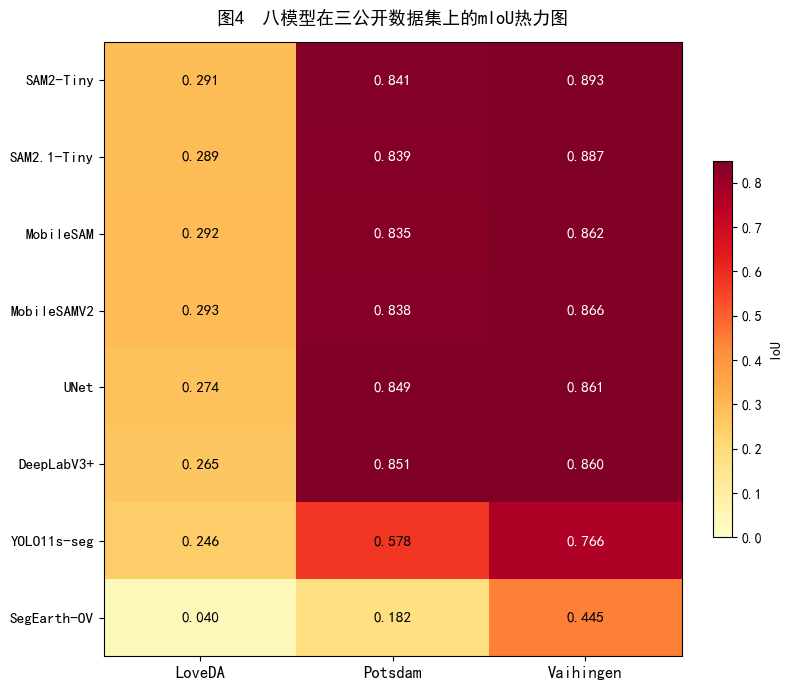

In [6]:
# 图4：三数据集 × 八模型 mIoU 热力图
# ============================================================
# 图4：三公开数据集 × 八模型 mIoU 热力图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 数据：请将 None 替换为实际实验结果 ──
models = ['SAM2-Tiny', 'SAM2.1-Tiny', 'MobileSAM', 'MobileSAMV2',
          'UNet', 'DeepLabV3+', 'YOLO11s-seg', 'SegEarth-OV']
datasets = ['LoveDA', 'Potsdam', 'Vaihingen']

# iou_matrix[i][j] = 模型i在数据集j上的IoU（待填充）
iou_matrix = np.array([
    [None, None, None],   # SAM2-Tiny
    [None, None, None],   # SAM2.1-Tiny
    [None, None, None],   # MobileSAM
    [None, None, None],   # MobileSAMV2
    [None, None, None],   # UNet
    [None, None, None],   # DeepLabV3+
    [None, None, None],   # YOLO11s-seg
    [None, None, None],   # SegEarth-OV
], dtype=object)

# 示例数值（删除后替换为真实结果）
iou_matrix = np.array([
    [0.2906, 0.8410, 0.8933],
    [0.2889, 0.8387, 0.8868],
    [0.2924, 0.8348, 0.8620],
    [0.2934, 0.8377, 0.8656],
    [0.2738, 0.8494, 0.8611],
    [0.2650, 0.8506, 0.8598],
    [0.2460, 0.5775, 0.7663],
    [0.0401, 0.1820, 0.4450],
], dtype=float)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(iou_matrix, cmap='YlOrRd', vmin=0, vmax=0.85, aspect='auto')

ax.set_xticks(range(len(datasets)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(datasets, fontsize=12)
ax.set_yticklabels(models, fontsize=11)

# 添加数值注释
for i in range(len(models)):
    for j in range(len(datasets)):
        val = iou_matrix[i, j]
        color = 'white' if val > 0.65 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='IoU', fraction=0.03)
ax.set_title('图4  八模型在三公开数据集上的mIoU热力图', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('fig4_heatmap_cross_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

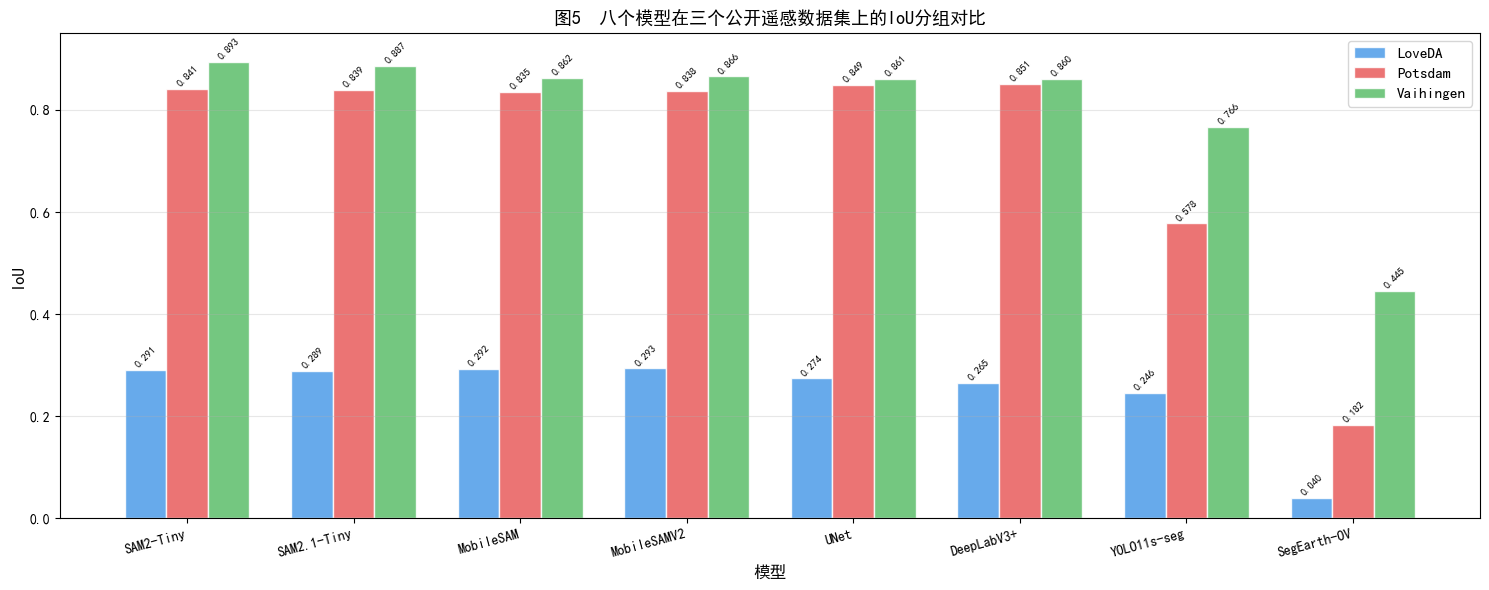

In [7]:
# 图5：三数据集 × 八模型 IoU 分组柱状图
# ============================================================
# 图5：三数据集 × 八模型 IoU 分组柱状图（与图4互补）
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

models = ['SAM2-Tiny', 'SAM2.1-Tiny', 'MobileSAM', 'MobileSAMV2',
          'UNet', 'DeepLabV3+', 'YOLO11s-seg', 'SegEarth-OV']
datasets = ['LoveDA', 'Potsdam', 'Vaihingen']
COLORS = ['#4C9BE8', '#E85C5C', '#5CBE6A']

# ── 数据（请替换）──
iou_matrix = np.array([
    [0.2906, 0.8410, 0.8933],
    [0.2889, 0.8387, 0.8868],
    [0.2924, 0.8348, 0.8620],
    [0.2934, 0.8377, 0.8656],
    [0.2738, 0.8494, 0.8611],
    [0.2650, 0.8506, 0.8598],
    [0.2460, 0.5775, 0.7663],
    [0.0401, 0.1820, 0.4450],
], dtype=float)

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

for i, (ds, color) in enumerate(zip(datasets, COLORS)):
    bars = ax.bar(x + i*width, iou_matrix[:, i], width,
                  label=ds, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, iou_matrix[:, i]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xlabel('模型', fontsize=12)
ax.set_ylabel('IoU', fontsize=12)
ax.set_title('图5  八个模型在三个公开遥感数据集上的IoU分组对比', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 0.95)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_grouped_bar_cross_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

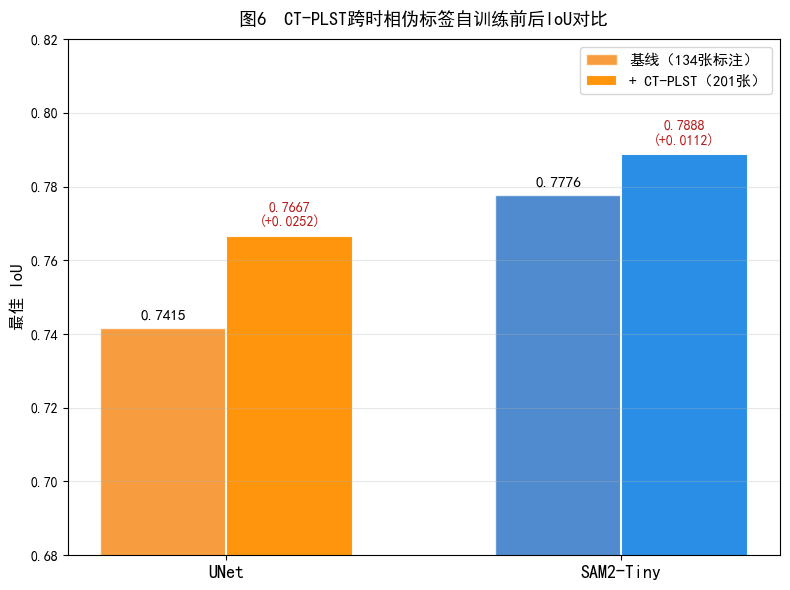

In [8]:
# 图6：自训练前后IoU对比图（含两个模型）
# ============================================================
# 图6：CT-PLST 自训练前后 IoU 对比（UNet 和 SAM2-Tiny）
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

models = ['UNet', 'SAM2-Tiny']
baseline_iou = [0.7415, 0.7776]
selftraining_iou = [0.7667, 0.7888]
improvements = [selftraining_iou[i] - baseline_iou[i] for i in range(2)]

x = np.arange(len(models))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - width/2, baseline_iou, width,
               label='基线（134张标注）',
               color=['#F57C00', '#1565C0'], alpha=0.75, edgecolor='white')
bars2 = ax.bar(x + width/2, selftraining_iou, width,
               label='+ CT-PLST（201张）',
               color=['#FF8F00', '#1E88E5'], alpha=0.95, edgecolor='white',
               linewidth=1.5)

# 标注数值
for bar, val in zip(bars1, baseline_iou):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
for bar, val, imp in zip(bars2, selftraining_iou, improvements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}\n(+{imp:.4f})', ha='center', va='bottom',
            fontsize=10, color='#B71C1C', fontweight='bold')

ax.set_ylabel('最佳 IoU', fontsize=12)
ax.set_title('图6  CT-PLST跨时相伪标签自训练前后IoU对比', fontsize=13, pad=10)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13)
ax.set_ylim(0.68, 0.82)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_self_training_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_600/3674733419.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(x, n_samples, 'r-o', linewidth=2, markersize=8,


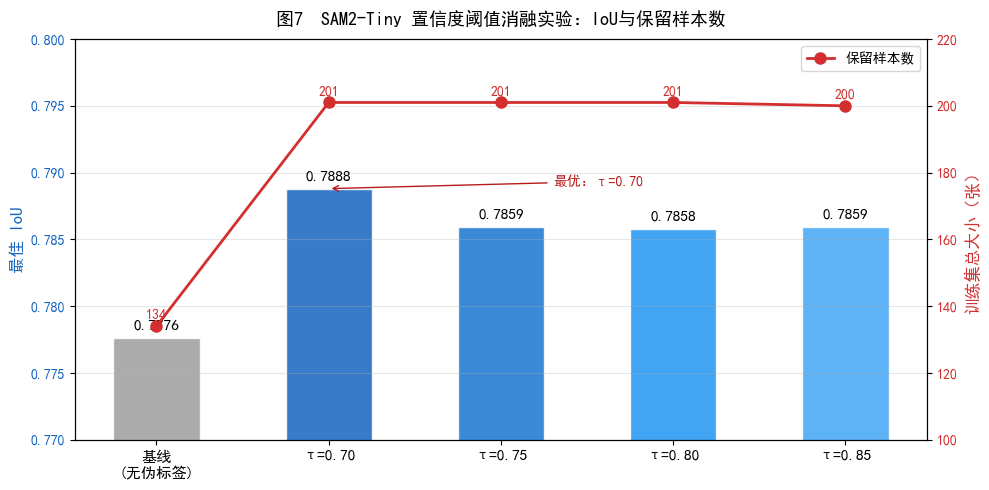

In [9]:
# 图7：置信度阈值消融实验结果图
# ============================================================
# 图7：置信度阈值 τ 消融实验（SAM2-Tiny）
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

thresholds = ['基线\n(无伪标签)', 'τ=0.70', 'τ=0.75', 'τ=0.80', 'τ=0.85']
iou_vals  = [0.7776, 0.7888, 0.7859, 0.7858, 0.7859]
n_samples = [134,    201,    201,    201,    200]

x = np.arange(len(thresholds))
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

colors = ['#9E9E9E', '#1565C0', '#1976D2', '#2196F3', '#42A5F5']
bars = ax1.bar(x, iou_vals, color=colors, width=0.5, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, iou_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.plot(x, n_samples, 'r-o', linewidth=2, markersize=8,
         label='保留样本数', color='#D32F2F')
for xi, n in zip(x, n_samples):
    ax2.text(xi, n + 1.5, str(n), ha='center', va='bottom',
             fontsize=10, color='#D32F2F')

ax1.set_ylabel('最佳 IoU', fontsize=12, color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')
ax2.set_ylabel('训练集总大小（张）', fontsize=12, color='#D32F2F')
ax2.tick_params(axis='y', labelcolor='#D32F2F')
ax2.set_ylim(100, 220)

ax1.set_xticks(x)
ax1.set_xticklabels(thresholds, fontsize=11)
ax1.set_ylim(0.77, 0.800)
ax1.set_title('图7  SAM2-Tiny 置信度阈值消融实验：IoU与保留样本数', fontsize=13, pad=10)
ax1.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper right', fontsize=10)

# 最优阈值标注
ax1.annotate('最优：τ=0.70', xy=(1, 0.7888), xytext=(2.3, 0.7890),
             arrowprops=dict(arrowstyle='->', color='#B71C1C'),
             fontsize=10, color='#B71C1C', fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_confidence_ablation.png', dpi=200, bbox_inches='tight')
plt.show()

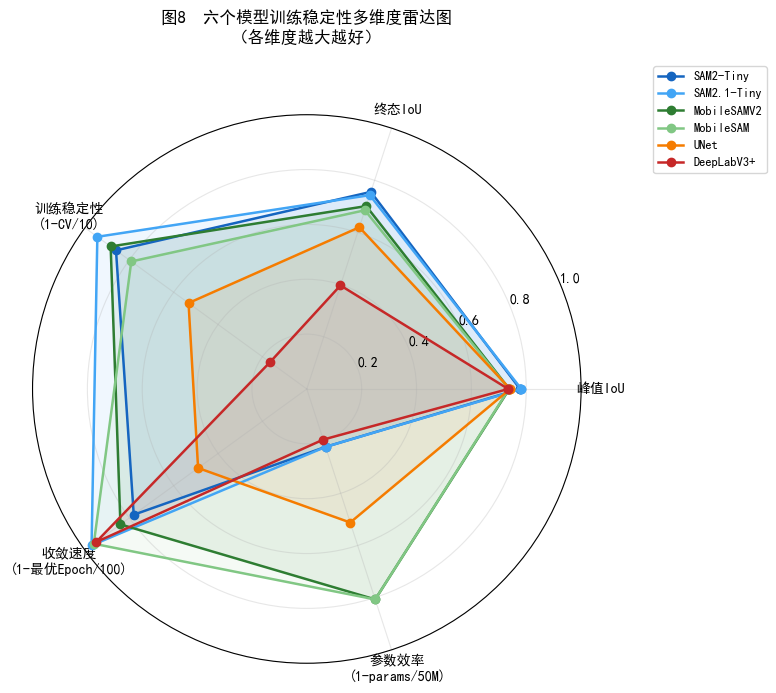

In [10]:
# 图8：训练稳定性雷达图（多维度对比）
# ============================================================
# 图8：六模型训练稳定性多维度雷达图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

categories = ['峰值IoU', '终态IoU', '训练稳定性\n(1-CV/10)', '收敛速度\n(1-最优Epoch/100)', '参数效率\n(1-params/50M)']
N = len(categories)

# 数据归一化到[0,1]（越高越好）
data = {
    'SAM2-Tiny':   [0.7776, 0.7555, 1-1.40/10,  1-22/100, 1-38.9/50],
    'SAM2.1-Tiny': [0.7821, 0.7431, 1-0.56/10,  1-3/100,  1-38.9/50],
    'MobileSAMV2': [0.7382, 0.7011, 1-1.16/10,  1-16/100, 1-9.66/50],
    'MobileSAM':   [0.7369, 0.6852, 1-2.09/10,  1-4/100,  1-9.66/50],
    'UNet':        [0.7415, 0.6199, 1-4.67/10,  1-51/100, 1-24.4/50],
    'DeepLabV3+':  [0.7345, 0.3970, 1-8.34/10,  1-5/100,  1-40.3/50],
}

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_list = ['#1565C0','#42A5F5','#2E7D32','#81C784','#F57C00','#C62828']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (model_name, vals), color in zip(data.items(), colors_list):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=1.8, color=color, label=model_name)
    ax.fill(angles, vals_plot, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('图8  六个模型训练稳定性多维度雷达图\n（各维度越大越好）',
             fontsize=12, pad=20, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_radar_stability.png', dpi=200, bbox_inches='tight')
plt.show()

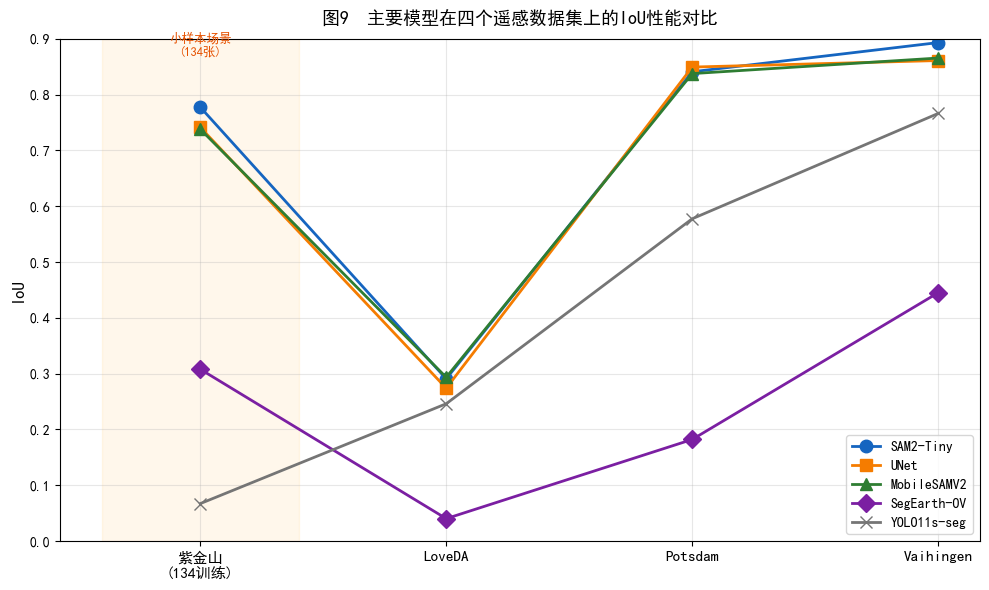

In [11]:
# 图9：四数据集综合性能对比折线图
# ============================================================
# 图9：主要模型在四个数据集上的IoU性能折线图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

datasets = ['紫金山\n(134训练)', 'LoveDA', 'Potsdam', 'Vaihingen']


# ── 数据（请将?替换为实际结果）──
results = {
    'SAM2-Tiny':  [0.7776, None, None, None],   # 替换None
    'UNet':       [0.7415, None, None, None],
    'MobileSAMV2':[0.7382, None, None, None],
    'SegEarth-OV':[0.3079, None, None, None],
    'YOLO11s-seg':[0.0670, None, None, None],
}

# 示例填充（删除后用真实值替换）
results = {
    'SAM2-Tiny':  [0.7776, 0.2906, 0.8410, 0.8933],
    'UNet':       [0.7415, 0.2738, 0.8494, 0.8611],
    'MobileSAMV2':[0.7382, 0.2934, 0.8377, 0.8656],
    'SegEarth-OV':[0.3079, 0.0401, 0.1820, 0.4450],
    'YOLO11s-seg':[0.0670, 0.2460, 0.5775, 0.7663],
}

colors_m = {
    'SAM2-Tiny': '#1565C0', 'UNet': '#F57C00',
    'MobileSAMV2': '#2E7D32', 'SegEarth-OV': '#7B1FA2',
    'YOLO11s-seg': '#757575'
}
markers = {'SAM2-Tiny':'o','UNet':'s','MobileSAMV2':'^','SegEarth-OV':'D','YOLO11s-seg':'x'}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(datasets))

for model, iou_list in results.items():
    ax.plot(x, iou_list, marker=markers[model], linewidth=2, markersize=9,
            color=colors_m[model], label=model)

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel('IoU', fontsize=12)
ax.set_ylim(0, 0.90)
ax.set_title('图9  主要模型在四个遥感数据集上的IoU性能对比', fontsize=13, pad=10)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

# 标注小样本区域
ax.axvspan(-0.4, 0.4, alpha=0.08, color='orange', label='小样本场景')
ax.text(0, 0.87, '小样本场景\n(134张)', ha='center', fontsize=9, color='#E65100')

plt.tight_layout()
plt.savefig('fig9_cross_dataset_line.png', dpi=200, bbox_inches='tight')
plt.show()